# XGBoost — Strategy A: SMOTE Oversampling

XGBoost is trained using SMOTE oversampling to address class imbalance between diabetic and non-diabetic participants. SMOTE is applied inside the cross-validation pipeline so that synthetic samples are generated only on training folds, preventing data leakage into the validation fold.

Hyperparameter tuning is performed using `RandomizedSearchCV` with 10-fold stratified cross-validation. The trained model is saved to disk after the first run so that subsequent runs load the fitted model directly, avoiding the cost of rerunning tuning and cross-validation.

Feature importance is assessed using three methods to support the research on explainability consistency:
- **SHAP** (TreeExplainer): model-agnostic, interaction-aware
- **Permutation Importance**: model-agnostic, based on test set performance drop
- **Built-in XGBoost Importance** (Gain): model-specific, based on average gain per split

**Exports:**
| File | Contents |
|------|----------|
| `models/xgboost_A.pkl` | Fitted pipeline (SMOTE + XGBClassifier) |
| `results/xgboost/xgboost_A_metrics.csv` | Scalar performance metrics |
| `results/xgboost/xgboost_A_feature_importance.csv` | Full feature rankings (all 3 methods) |
| `results/xgboost/xgboost_A_shap_explanation.pkl` | Full SHAP `Explanation` object (values + data + feature names) |
| `results/xgboost/xgboost_A_predictions.pkl` | Dict with `y_test`, `predictions`, `pred_probabilities` |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, classification_report,
    precision_score, recall_score, f1_score,
)

## Loading the Preprocessed Dataset

The preprocessed training and test sets are loaded from Parquet files produced by `04_preprocessing.ipynb`. These datasets have already been imputed, encoded, and scaled. No further preprocessing is applied here.

In [2]:
X_train = pd.read_parquet("../../data/splits/X_train_unscaled.parquet")
X_test  = pd.read_parquet("../../data/splits/X_test_unscaled.parquet")
y_train = pd.read_parquet("../../data/splits/y_train.parquet")["diabetes"]
y_test  = pd.read_parquet("../../data/splits/y_test.parquet")["diabetes"]

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (20800, 43)
Test shape:  (5200, 43)


## Hyperparameter Tuning with Cross-Validation

`RandomizedSearchCV` with 10-fold stratified cross-validation is used to find the best hyperparameters. The search optimises for ROC AUC, which is appropriate given the class imbalance in the dataset.

The fitted model is saved to `models/xgboost_A.pkl` after the first run. On subsequent runs the saved model is loaded directly, skipping tuning entirely. To retune from scratch, delete the `.pkl` file and rerun this cell.

In [3]:
MODEL_PATH = "../../models/xgboost_A.pkl"
os.makedirs("../../models", exist_ok=True)

if os.path.exists(MODEL_PATH):
    best_model = joblib.load(MODEL_PATH)
    print("[OK] Model loaded from disk.")
else:
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    param_grid = {
        "model__n_estimators":     [100, 200, 300, 500],
        "model__max_depth":        [2, 3, 4, 5],
        "model__learning_rate":    [0.01, 0.03, 0.05, 0.1],
        "model__subsample":        [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__gamma":            [0, 0.1, 0.3, 0.5]
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=100,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_

    print("Best parameters:", random_search.best_params_)
    print("Best CV PR AUC:", random_search.best_score_)

    joblib.dump(best_model, MODEL_PATH)
    print("[OK] Model saved to", MODEL_PATH)

[OK] Model loaded from disk.


## Final Test Set Evaluation

The best model is evaluated on the held-out test set. The test set is never resampled and preserves the original class distribution, so that evaluation reflects real-world performance.

Performance is measured using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

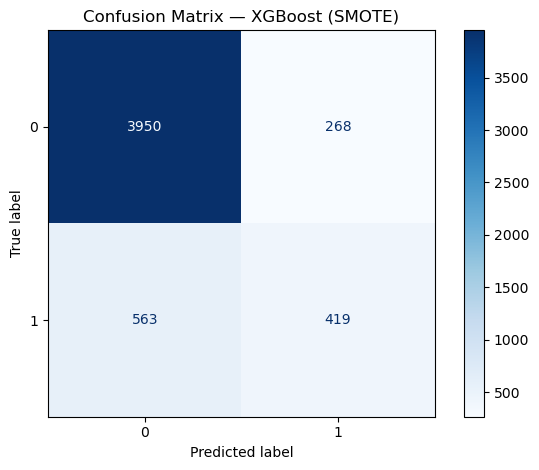

Accuracy:  0.8402
ROC AUC:   0.8540

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.90      4218
           1       0.61      0.43      0.50       982

    accuracy                           0.84      5200
   macro avg       0.74      0.68      0.70      5200
weighted avg       0.83      0.84      0.83      5200



In [4]:
pred_probabilities = best_model.predict_proba(X_test)[:, 1]
predictions        = best_model.predict(X_test)

cm   = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (SMOTE)")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_test, predictions)
roc_auc  = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

## Exporting Model Performance Metrics

Scalar evaluation metrics are exported to a CSV file in `results/xgboost/`. This allows the comparison notebook to load results from all models without retraining.

Raw prediction arrays (`y_test`, `predictions`, `pred_probabilities`) are saved as a `.pkl` file so the comparison notebook can reconstruct confusion matrices and precision-recall curves without re-running inference.

In [5]:
RESULTS_DIR = "../../results/xgboost"
os.makedirs(RESULTS_DIR, exist_ok=True)

metrics = {
    "Model":     "XGBoost",
    "Strategy":  "SMOTE",
    "Accuracy":  accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall":    recall_score(y_test, predictions),
    "F1-score":  f1_score(y_test, predictions),
    "ROC AUC":   roc_auc_score(y_test, pred_probabilities),
}
pd.DataFrame([metrics]).to_csv(
    f"{RESULTS_DIR}/xgboost_A_metrics.csv", index=False
)
print("[OK] Performance metrics CSV saved.")

predictions_payload = {
    "y_test":             y_test,
    "predictions":        predictions,
    "pred_probabilities": pred_probabilities,
}
joblib.dump(predictions_payload, f"{RESULTS_DIR}/xgboost_A_predictions.pkl")
print("[OK] Predictions pkl saved.")

[OK] Performance metrics CSV saved.
[OK] Predictions pkl saved.


## Feature Importance — SHAP (TreeExplainer)

`shap.TreeExplainer` computes exact Shapley values for tree-based models. For each test observation, SHAP assigns a contribution value to every feature, indicating how much that feature pushed the prediction above or below the base rate. The mean absolute SHAP value across all test observations is used as the overall importance score.

The full `shap.Explanation` object is also exported so that SHAP plots and explanations can be reused later without recomputing SHAP values.

[OK] SHAP Explanation object saved.


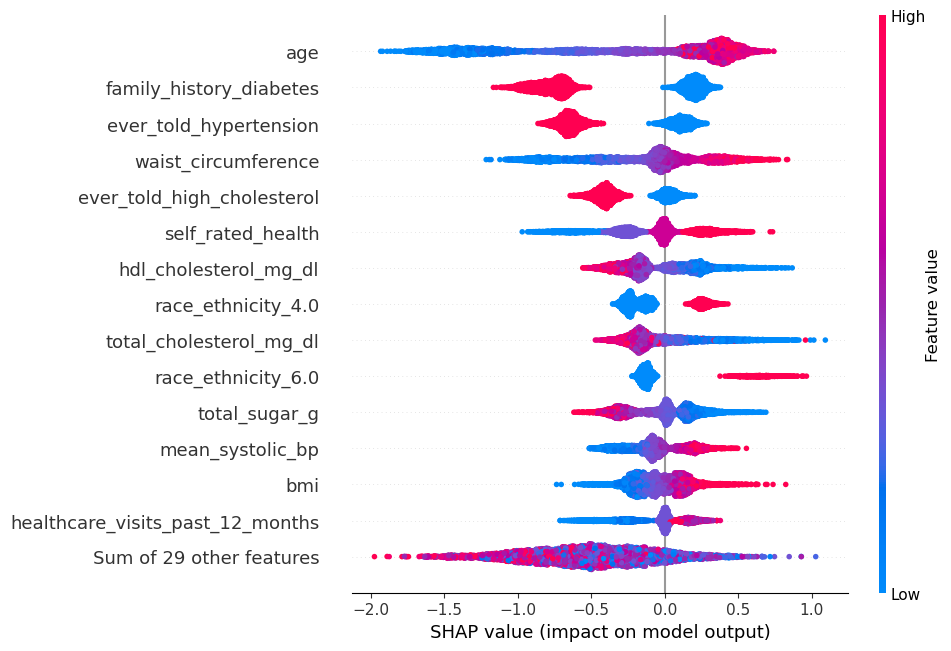

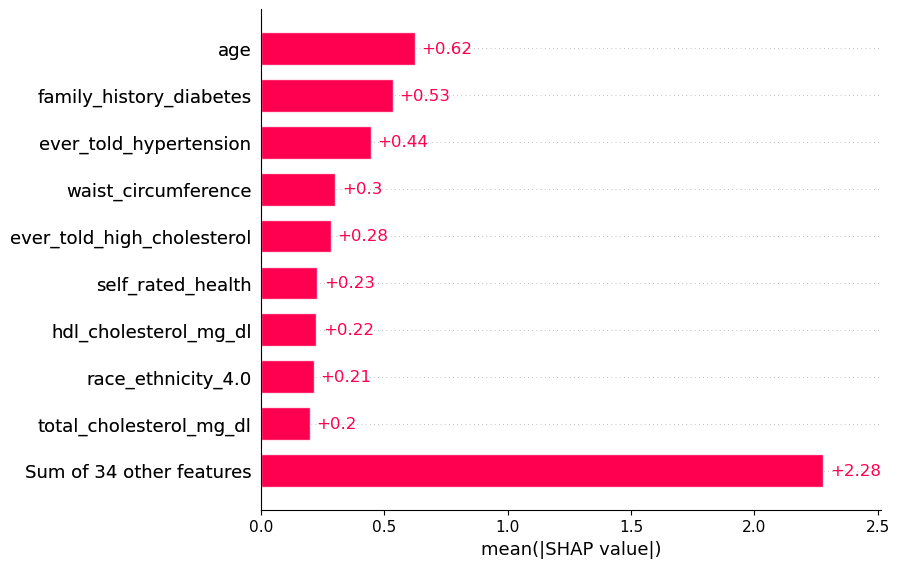

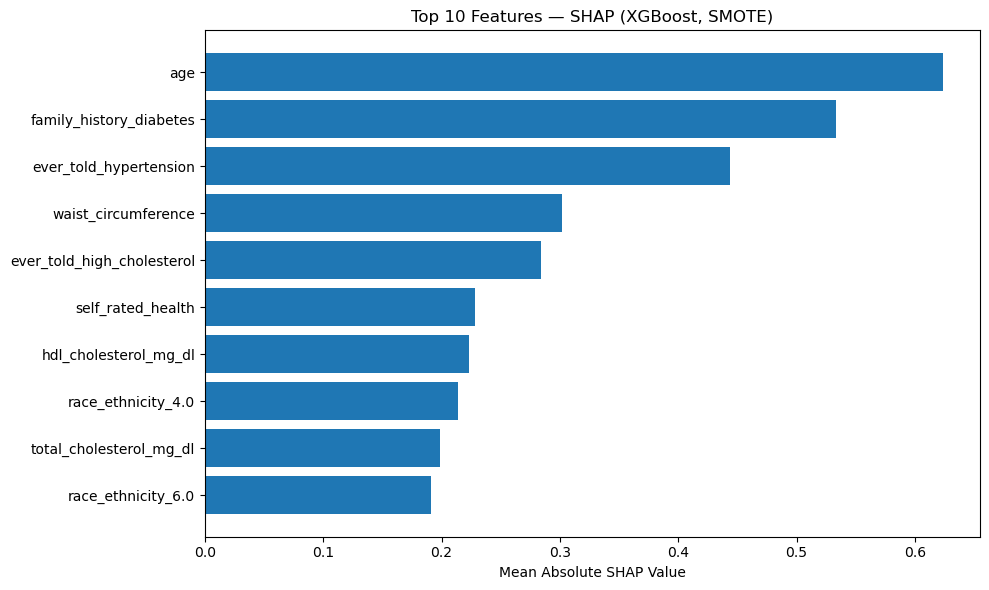

In [6]:
xgb_model   = best_model.named_steps["model"]
X_test_shap = X_test.astype(np.float64)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

shap_explanation = shap.Explanation(
    values       = shap_values,
    base_values  = explainer.expected_value,
    data         = X_test_shap.values,
    feature_names= list(X_test.columns)
)

RESULTS_DIR = "../../results/xgboost"
os.makedirs(RESULTS_DIR, exist_ok=True)

joblib.dump(shap_explanation, f"{RESULTS_DIR}/xgboost_A_shap_explanation.pkl")
print("[OK] SHAP Explanation object saved.")

shap.plots.beeswarm(shap_explanation, max_display=15, show=True)

shap.plots.bar(shap_explanation, max_display=10, show=True)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature":    X_test.columns,
    "Importance": mean_abs_shap
}).sort_values("Importance", ascending=False).reset_index(drop=True)

shap_df["Rank"]     = range(1, len(shap_df) + 1)
shap_df["Model"]    = "XGBoost"
shap_df["Strategy"] = "SMOTE"
shap_df["Method"]   = "SHAP"

# Quick bar chart (top 10)
top10 = shap_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 10 Features — SHAP (XGBoost, SMOTE)")
plt.tight_layout()
plt.show()

## Feature Importance — Permutation Importance

Permutation importance measures how much the model's ROC AUC drops when the values of a single feature are randomly shuffled. A large drop indicates that the model relies heavily on that feature; a small or negative drop suggests the feature contributes little.

Permutation importance is computed on the full pipeline using the held-out test set. `n_repeats=20` shuffles each feature 20 times to reduce variance in the estimate.

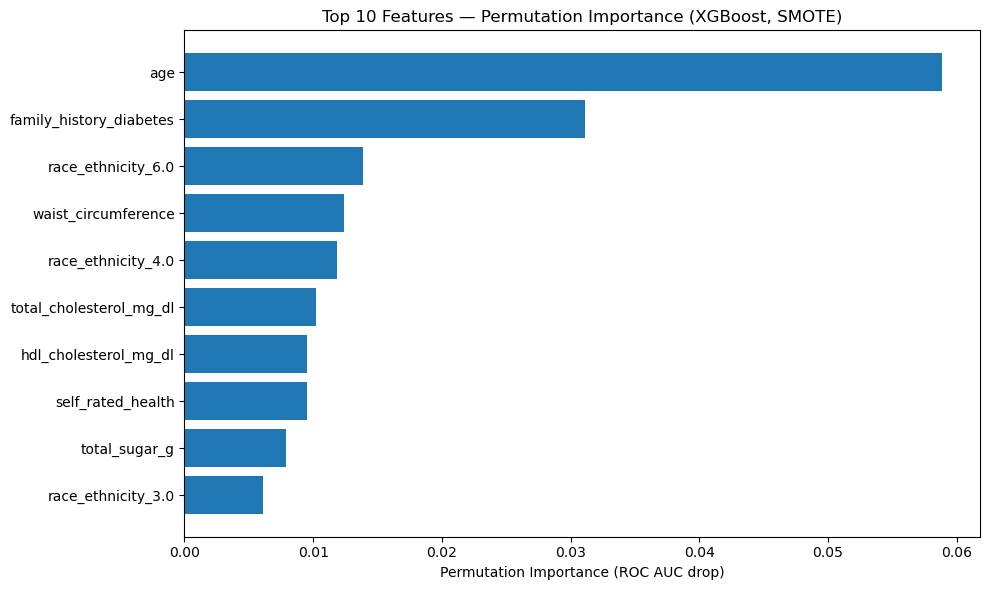

In [7]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "Feature":        X_test.columns,
    "Importance":     perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values("Importance", ascending=False).reset_index(drop=True)

perm_df["Rank"]     = range(1, len(perm_df) + 1)
perm_df["Model"]    = "XGBoost"
perm_df["Strategy"] = "SMOTE"
perm_df["Method"]   = "Permutation"

# Plot top 10
top10 = perm_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Permutation Importance (ROC AUC drop)")
plt.title("Top 10 Features — Permutation Importance (XGBoost, SMOTE)")
plt.tight_layout()
plt.show()

## Feature Importance — Built-in XGBoost Importance (Gain)

XGBoost provides a model-specific importance score based on the average gain per feature split across all trees. Gain measures how much a feature improves the loss function each time it is used for a split, averaged over all splits and trees in which that feature appears.

`feature_importances_` from the sklearn API is used instead of `booster.get_score()`, because `get_score()` omits features that were never selected for a split, which would make the ranking incomplete and inconsistent with SHAP and permutation importance.

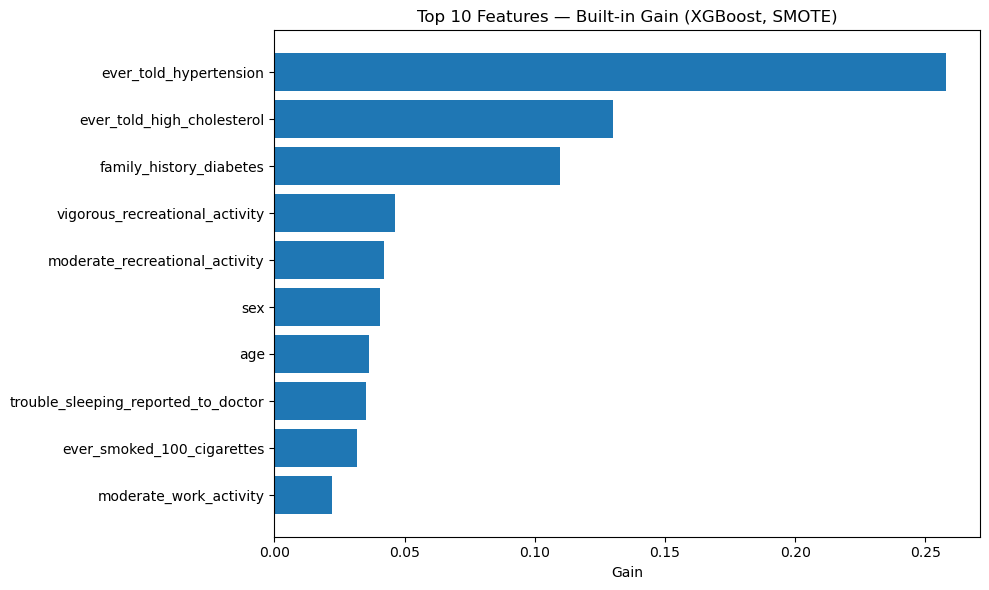

In [8]:
xgb_model = best_model.named_steps["model"]

builtin_df = pd.DataFrame({
    "Feature":    X_test.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

builtin_df["Rank"]     = range(1, len(builtin_df) + 1)
builtin_df["Model"]    = "XGBoost"
builtin_df["Strategy"] = "SMOTE"
builtin_df["Method"]   = "XGBoost Gain"

# Plot top 10
top10 = builtin_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Gain")
plt.title("Top 10 Features — Built-in Gain (XGBoost, SMOTE)")
plt.tight_layout()
plt.show()

## Exporting Feature Importance Rankings

All three importance rankings are combined into a single CSV file in `results/xgboost/`. Each row represents one feature under one method, with its importance score and rank. The full ranking (not just top 10) is saved so that Spearman rank correlations can be computed across all features in the comparison notebook.

In [9]:
RESULTS_DIR = "../../results/xgboost"
os.makedirs(RESULTS_DIR, exist_ok=True)

cols = ["Model", "Strategy", "Method", "Rank", "Feature", "Importance"]

feature_importance_all = pd.concat([
    shap_df[cols],
    perm_df[cols],
    builtin_df[cols]
], ignore_index=True)

feature_importance_all.to_csv(
    f"{RESULTS_DIR}/xgboost_A_feature_importance.csv", index=False
)
print("[OK] Feature importance rankings saved.")
display(feature_importance_all.head(15))

[OK] Feature importance rankings saved.


,Model,Strategy,Method,Rank,Feature,Importance
0,XGBoost,SMOTE,SHAP,1,age,0.623901
1,XGBoost,SMOTE,SHAP,2,family_history_diabetes,0.533459
2,XGBoost,SMOTE,SHAP,3,ever_told_hypertension,0.443876
3,XGBoost,SMOTE,SHAP,4,waist_circumference,0.301605
4,XGBoost,SMOTE,SHAP,5,ever_told_high_cholesterol,0.283878
5,XGBoost,SMOTE,SHAP,6,self_rated_health,0.228326
6,XGBoost,SMOTE,SHAP,7,hdl_cholesterol_mg_dl,0.223551
7,XGBoost,SMOTE,SHAP,8,race_ethnicity_4.0,0.213761
8,XGBoost,SMOTE,SHAP,9,total_cholesterol_mg_dl,0.198533
9,XGBoost,SMOTE,SHAP,10,race_ethnicity_6.0,0.190938
